# Persistent (Co)homology of PFC Manifold Structure — Wake & Sleep

Tests whether PFC population activity lies on a low-dimensional **topological
manifold** (primarily a cyclic ring **S¹** reflecting the A→B→C→D→A task) and
whether it is **preserved during sleep**.

Heavy computation is done by `mFC_data/code/run_ph_batch.py` on SLURM (see
`sbatch_files/ph_pfc.sbatch` / `submit_ph_lec.sh`); this notebook **loads the
cached pickles and plots**. Companion of `cyclic_structure_analysis.py` (which
tests cyclic *geometry*, not *topology*).

**Pipeline:** timepoint population vectors → smooth + z-score + PCA → max-min
landmarks → ripser H0–H2 (Z/2, Z/3) → per-neuron circular-shift shuffle null →
DREiMac circular coordinate → related to behaviour; sleep done de novo **and** by
projection onto the wake manifold.

**PFC notes:** neuron counts vary per recday (1–117; recdays with <12 neurons are skipped) and there is **no head direction**, so the θ-vs-HD panel reads n/a. Sleep comes from joblib `binned_FR_dic_*` files with the same neurons as wake.

In [1]:
# --- setup ---
import os, sys, glob
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload
sys.path.insert(0, os.path.abspath('.'))
import persistent_homology_analysis as ph; reload(ph)
import glm_analysis_v2 as glm
glm.apply_gridmaze_style()

# Point at the SLURM output dir; falls back to the smoke-test dir so the
# notebook runs before the full sweep has finished.
OUT_DIR = '../data/ph_outputs'
if not glob.glob(os.path.join(OUT_DIR, '*.pkl')):
    OUT_DIR = '../data/ph_outputs_smoketest'
SAVE_DIR = '../data/ph_outputs/figures'
SAVE_FIGS = True
# per-session figure loops: cap how many sessions to plot
# (the full sweep has 100s of sessions; set higher/None-slice to see more)
MAX_PLOT = 3
print('loading from', OUT_DIR)

loading from ../data/ph_outputs


## Load results + summary table

In [2]:
results = ph.load_ph_outputs(OUT_DIR)
print(f'{len(results)} result file(s)')
df = ph.summarise(results)
df

743 result file(s)


,stem,mouse_recday,state,n_neurons,n_points,H1_top,H1_ratio,H1_p,H2_top,H2_ratio,...,replay_coverage,replay_p_continuity,replay_continuity_ratio,net_revolutions,task_phase_R,task_phase_p,goal_progress_R,goal_progress_p,head_direction_R,head_direction_p
0,ab03_01092023_02092023__sleep_sb0,ab03_01092023_02092023,sleep,63,36514,0.783977,1.028646,0.079208,0.463323,1.041210,...,0.003274,0.004975,7.943756,0.010345,NaN,NaN,NaN,NaN,NaN,NaN
1,ab03_01092023_02092023__sleep_sb1,ab03_01092023_02092023,sleep,63,12089,1.029802,1.154697,0.009901,0.498726,1.109867,...,0.002242,0.004975,6.230629,0.005153,NaN,NaN,NaN,NaN,NaN,NaN
2,ab03_01092023_02092023__sleep_sb10,ab03_01092023_02092023,sleep,63,12188,0.823512,1.071356,0.069307,0.458874,1.059926,...,0.000032,0.004975,3.497781,0.000031,NaN,NaN,NaN,NaN,NaN,NaN
3,ab03_01092023_02092023__sleep_sb11,ab03_01092023_02092023,sleep,63,12319,1.063968,1.336350,0.009901,0.591093,1.092853,...,0.000979,0.004975,5.879587,0.004135,NaN,NaN,NaN,NaN,NaN,NaN
4,ab03_01092023_02092023__sleep_sb12,ab03_01092023_02092023,sleep,63,12219,0.794465,1.056829,0.079208,0.442075,1.042411,...,0.011479,0.004975,7.195721,0.000004,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
579,me11_12122021_13122021__wake_s1,me11_12122021_13122021,wake,12,9043,0.577915,1.037491,0.465347,0.298078,1.033373,...,NaN,NaN,NaN,NaN,0.050832,0.990010,0.026088,0.450549,NaN,NaN
580,me11_12122021_13122021__wake_s3,me11_12122021_13122021,wake,12,8580,0.674797,1.212809,0.138614,0.278395,1.013199,...,NaN,NaN,NaN,NaN,0.095270,0.135864,0.027986,0.625375,NaN,NaN
581,me11_12122021_13122021__wake_s5,me11_12122021_13122021,wake,12,6187,0.790685,1.208358,0.099010,0.288519,1.040522,...,NaN,NaN,NaN,NaN,0.158772,0.381618,0.056551,0.210789,NaN,NaN
582,me11_12122021_13122021__wake_s6,me11_12122021_13122021,wake,12,8441,0.564283,1.137988,0.564356,0.274011,1.010575,...,NaN,NaN,NaN,NaN,0.100929,0.526474,0.030366,0.263736,NaN,NaN


In [3]:
# split wake / sleep for convenience
wake  = {k: v for k, v in results.items() if v.get('state') == 'wake'}
sleep = {k: v for k, v in results.items() if v.get('state') == 'sleep'}
print(f'wake sessions: {len(wake)}   sleep boxes: {len(sleep)}')

wake sessions: 137   sleep boxes: 447


## Fig 1 — Persistence diagrams, barcodes & significance (per wake session)

A genuine ring shows **one** H1 bar far above the rest and above the shuffle
null; H2 stays at noise. Equal-length bars (ratio ≈ 1) = topological noise.

save_section('fig1_persistence_ab03_01092023_02092023__wake_s0'): wrote 1 file(s) to ../data/ph_outputs/figures


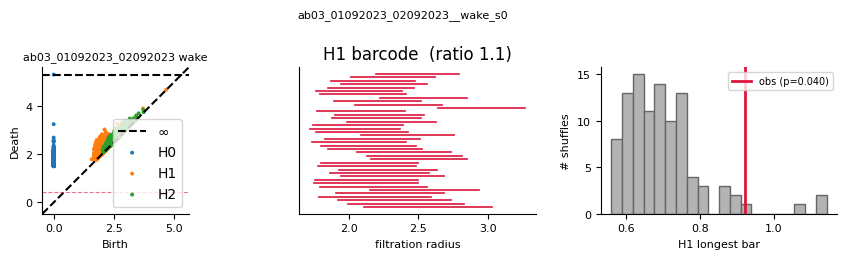

save_section('fig1_persistence_ab03_01092023_02092023__wake_s1'): wrote 1 file(s) to ../data/ph_outputs/figures


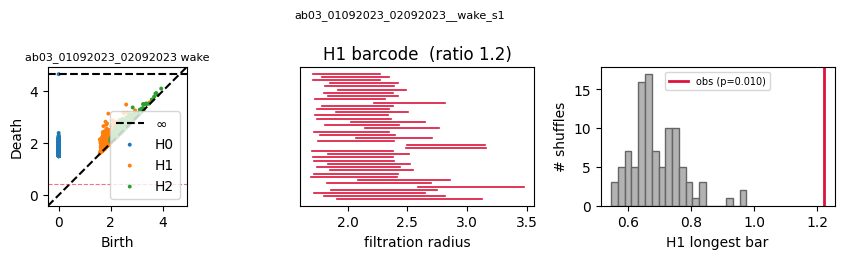

save_section('fig1_persistence_ab03_01092023_02092023__wake_s2'): wrote 1 file(s) to ../data/ph_outputs/figures


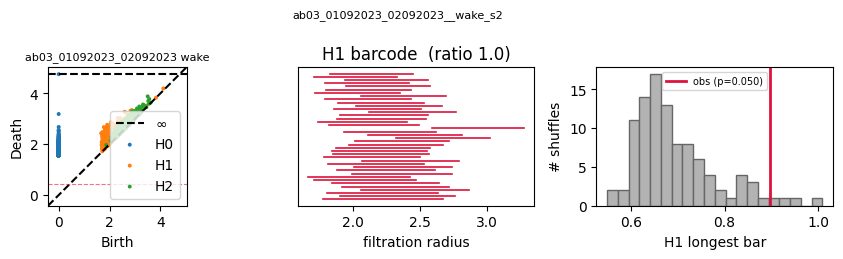

In [4]:
for stem, res in list(wake.items())[:MAX_PLOT]:
    fig, axes = plt.subplots(1, 3, figsize=(9, 2.6))
    ph.plot_persistence(res, ax=axes[0])
    ph.plot_barcode(res, dim=1, ax=axes[1])
    ph.plot_significance(res, dim=1, ax=axes[2])
    fig.suptitle(stem, fontsize=8); fig.tight_layout()
    if SAVE_FIGS: glm.save_section('fig1_persistence_'+stem, SAVE_DIR)
    plt.show()

## Fig 2 — Betti summary across sessions / mice

save_section('fig2_betti_summary'): wrote 1 file(s) to ../data/ph_outputs/figures


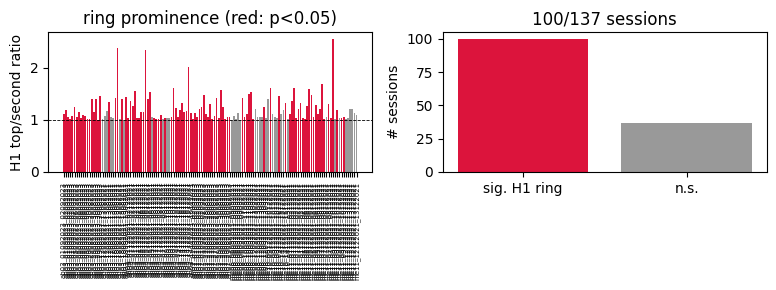

In [5]:
if len(df):
    wdf = df[df.state == 'wake'].reset_index(drop=True)
    fig, ax = plt.subplots(1, 2, figsize=(8, 3))
    x = np.arange(len(wdf))
    cols = ['crimson' if p < 0.05 else '0.6' for p in wdf['H1_p'].fillna(1)]
    ax[0].bar(x, wdf['H1_ratio'], color=cols)
    ax[0].axhline(1, ls='--', color='k', lw=0.6)
    ax[0].set_xticks(x); ax[0].set_xticklabels(wdf['mouse_recday'], rotation=90, fontsize=5)
    ax[0].set_ylabel('H1 top/second ratio'); ax[0].set_title('ring prominence (red: p<0.05)')
    n_sig = int((wdf['H1_p'] < 0.05).sum())
    ax[1].bar(['sig. H1 ring', 'n.s.'], [n_sig, len(wdf) - n_sig], color=['crimson', '0.6'])
    ax[1].set_ylabel('# sessions'); ax[1].set_title(f'{n_sig}/{len(wdf)} sessions')
    fig.tight_layout()
    if SAVE_FIGS: glm.save_section('fig2_betti_summary', SAVE_DIR)
    plt.show()

## Fig 3 — Circular coordinate vs behaviour

Does the decoded neural angle θ track the **circular task phase** (and goal
progress / head direction)? `R` = reflection-aware resultant length (1 = perfect,
~0 = chance); `p` from circular-shift shuffles.

save_section('fig3_coord_ab03_01092023_02092023__wake_s0'): wrote 1 file(s) to ../data/ph_outputs/figures


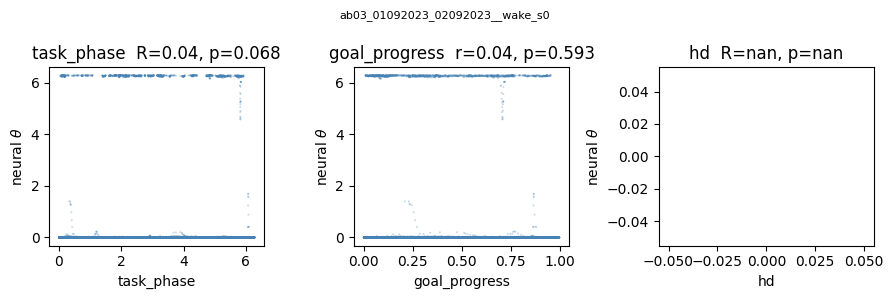

save_section('fig3_coord_ab03_01092023_02092023__wake_s1'): wrote 1 file(s) to ../data/ph_outputs/figures


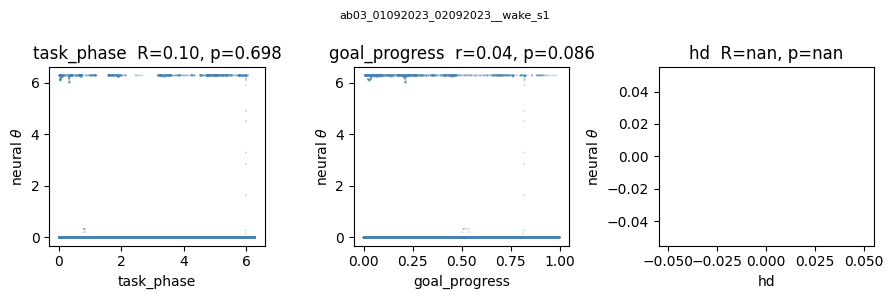

save_section('fig3_coord_ab03_01092023_02092023__wake_s2'): wrote 1 file(s) to ../data/ph_outputs/figures


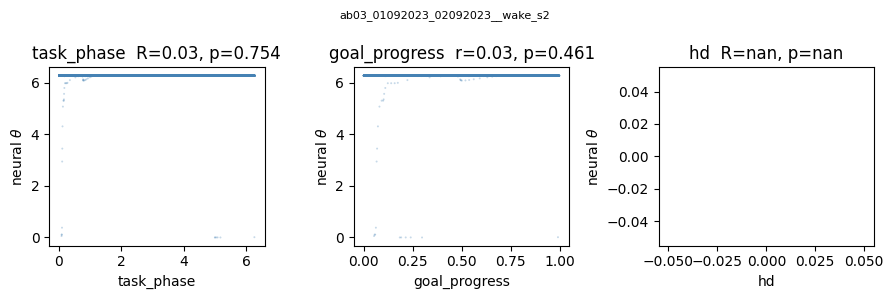

In [6]:
for stem, res in list(wake.items())[:MAX_PLOT]:
    if 'theta' not in res:
        continue
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    ph.plot_coord_vs_behaviour(res, 'task_phase',   ax=axes[0])
    ph.plot_coord_vs_behaviour(res, 'goal_progress', ax=axes[1], circular=False)
    ph.plot_coord_vs_behaviour(res, 'hd',           ax=axes[2])
    fig.suptitle(stem, fontsize=8); fig.tight_layout()
    if SAVE_FIGS: glm.save_section('fig3_coord_'+stem, SAVE_DIR)
    plt.show()

## Fig 4 — Manifold embedding (PCA cloud coloured by θ and task phase)

save_section('fig4_manifold_ab03_01092023_02092023__wake_s0'): wrote 1 file(s) to ../data/ph_outputs/figures


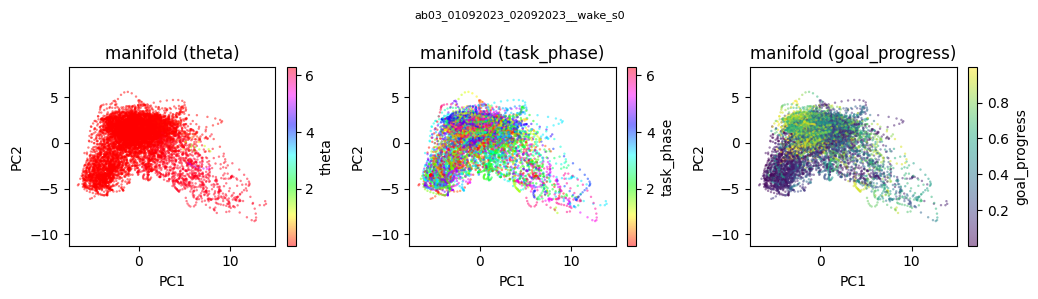

save_section('fig4_manifold_ab03_01092023_02092023__wake_s1'): wrote 1 file(s) to ../data/ph_outputs/figures


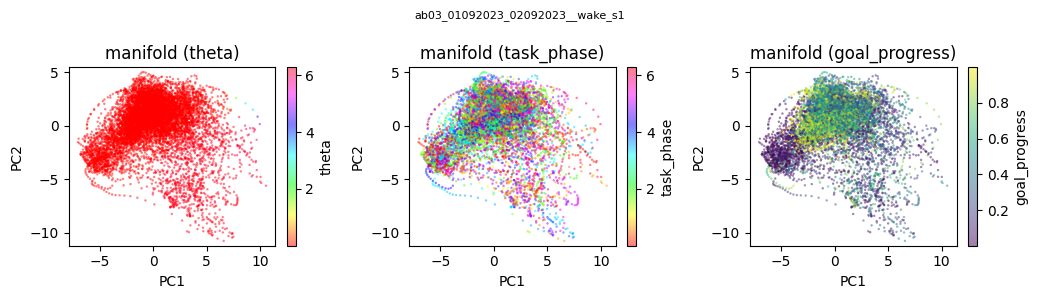

save_section('fig4_manifold_ab03_01092023_02092023__wake_s2'): wrote 1 file(s) to ../data/ph_outputs/figures


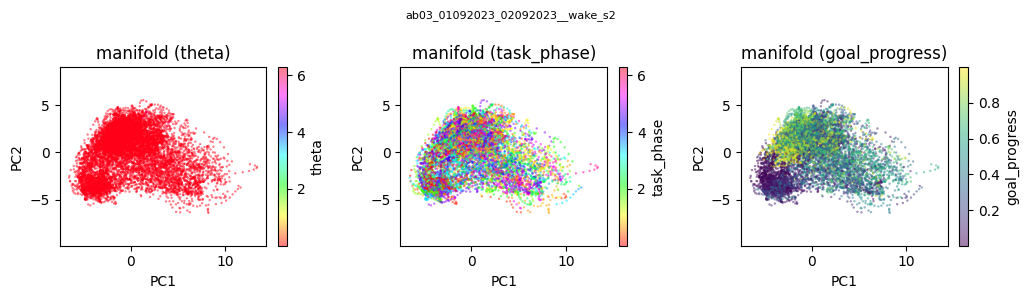

In [7]:
for stem, res in list(wake.items())[:MAX_PLOT]:
    if res.get('_X') is None:
        continue
    fig, axes = plt.subplots(1, 3, figsize=(10.5, 3))
    ph.plot_manifold(res, color_by='theta',         ax=axes[0])
    ph.plot_manifold(res, color_by='task_phase',    ax=axes[1])
    ph.plot_manifold(res, color_by='goal_progress', ax=axes[2])
    fig.suptitle(stem, fontsize=8); fig.tight_layout()
    if SAVE_FIGS: glm.save_section('fig4_manifold_'+stem, SAVE_DIR)
    plt.show()

## Fig 5 — Sleep: de novo topology + projection onto the wake ring

Left/middle: persistence + significance of the sleep cloud on its own.
Right: the wake circular coordinate decoded over sleep time — coherent cyclic
sweeps (high coherence, p small) indicate the manifold is traversed during
sleep (replay-like).

save_section('fig5_sleep_ab03_01092023_02092023__sleep_sb0'): wrote 1 file(s) to ../data/ph_outputs/figures


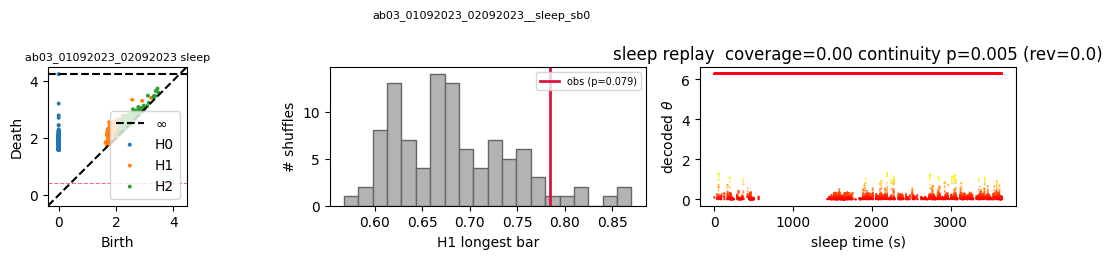

save_section('fig5_sleep_ab03_01092023_02092023__sleep_sb1'): wrote 1 file(s) to ../data/ph_outputs/figures


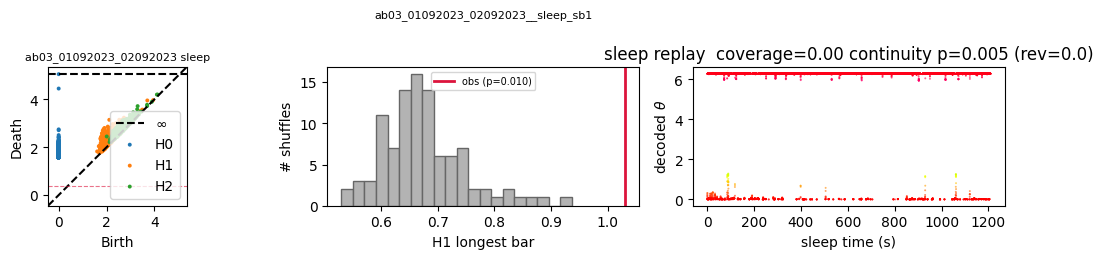

save_section('fig5_sleep_ab03_01092023_02092023__sleep_sb10'): wrote 1 file(s) to ../data/ph_outputs/figures


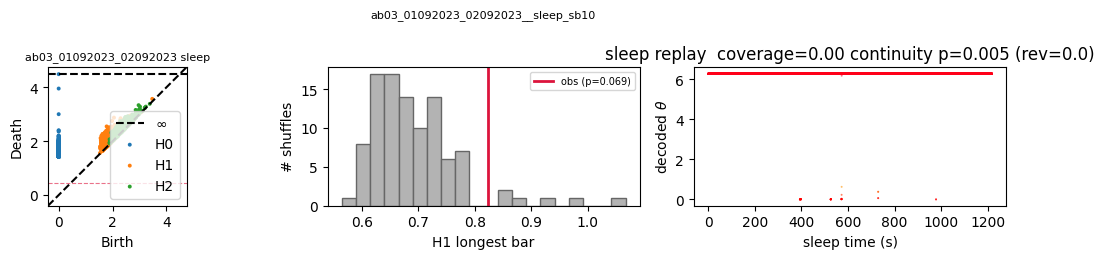

In [8]:
for stem, res in list(sleep.items())[:MAX_PLOT]:
    fig, axes = plt.subplots(1, 3, figsize=(11, 2.6))
    ph.plot_persistence(res, ax=axes[0])
    ph.plot_significance(res, dim=1, ax=axes[1])
    ph.plot_sleep_replay(res, ax=axes[2])
    fig.suptitle(stem, fontsize=8); fig.tight_layout()
    if SAVE_FIGS: glm.save_section('fig5_sleep_'+stem, SAVE_DIR)
    plt.show()

## Fig 6 — Wake vs sleep topology comparison

In [9]:
cols = ['mouse_recday', 'state', 'n_points', 'H1_top', 'H1_ratio', 'H1_p',
        'H2_top', 'H2_ratio']
extra = [c for c in ('task_phase_R', 'task_phase_p', 'replay_coverage', 'replay_p_continuity',
                     'net_revolutions') if c in df.columns]
df[cols + extra]

,mouse_recday,state,n_points,H1_top,H1_ratio,H1_p,H2_top,H2_ratio,task_phase_R,task_phase_p,replay_coverage,replay_p_continuity,net_revolutions
0,ab03_01092023_02092023,sleep,36514,0.783977,1.028646,0.079208,0.463323,1.041210,NaN,NaN,0.003274,0.004975,0.010345
1,ab03_01092023_02092023,sleep,12089,1.029802,1.154697,0.009901,0.498726,1.109867,NaN,NaN,0.002242,0.004975,0.005153
2,ab03_01092023_02092023,sleep,12188,0.823512,1.071356,0.069307,0.458874,1.059926,NaN,NaN,0.000032,0.004975,0.000031
3,ab03_01092023_02092023,sleep,12319,1.063968,1.336350,0.009901,0.591093,1.092853,NaN,NaN,0.000979,0.004975,0.004135
4,ab03_01092023_02092023,sleep,12219,0.794465,1.056829,0.079208,0.442075,1.042411,NaN,NaN,0.011479,0.004975,0.000004
...,...,...,...,...,...,...,...,...,...,...,...,...,...
579,me11_12122021_13122021,wake,9043,0.577915,1.037491,0.465347,0.298078,1.033373,0.050832,0.990010,NaN,NaN,NaN
580,me11_12122021_13122021,wake,8580,0.674797,1.212809,0.138614,0.278395,1.013199,0.095270,0.135864,NaN,NaN,NaN
581,me11_12122021_13122021,wake,6187,0.790685,1.208358,0.099010,0.288519,1.040522,0.158772,0.381618,NaN,NaN,NaN
582,me11_12122021_13122021,wake,8441,0.564283,1.137988,0.564356,0.274011,1.010575,0.100929,0.526474,NaN,NaN,NaN


## Diagnostic — smoothing sweep (live, one raw file)

The task cycle is slow (~tens of seconds), so the ring (if present) emerges only
once smoothing passes the fast spiking noise. This sweeps the smoothing kernel on
a single raw recording and reports the H1 prominence — handy for choosing
`smooth_sigma_bins` / `bin_ms`.

In [10]:
raw_file = '../data/Neuronal_activity/Awake/Neuron_raw_ah04_01122021_02122021_0.npy'
raw = np.load(raw_file, allow_pickle=True)
print(f'{"sigma_ms":>9} {"PC1-3var":>9} {"H1ratio":>8} {"H1top":>7}')
for sig in (2, 4, 8, 16, 32):
    cfg = ph.PHConfig(n_landmarks=600, coeff_fields=(2,), maxdim=1,
                      smooth_sigma_bins=sig, speed_filter_wake=False)
    X, _, model = ph.build_point_cloud(raw, cfg)
    s = ph.compute_persistence(X, cfg)['summary'][2][1]
    ev = model['pca'].explained_variance_ratio_[:3].sum()
    print(f'{sig*cfg.bin_ms:>9.0f} {ev:>9.2f} {s["gap_ratio"]:>8.2f} {s["top"]:>7.3f}')

 sigma_ms  PC1-3var  H1ratio   H1top


      200      0.16     1.14   0.942


      400      0.19     1.03   0.912


      800      0.24     1.09   1.169


     1600      0.27     1.00   1.517


     3200      0.29     1.11   3.164


## Fig 7 — Task-phase ring (trial-averaged) — the complementary test

Each point is one **task-phase bin** of the trial-averaged `Neurons_norm`
(360 = 4 states x 90 bins). Only 360 points, so **no landmarks / subsampling /
density trimming** — structurally immune to the outlier-arm artifact that made the
instantaneous clouds produce false H1 bars.

**Read `top/diam`, not H1.** The averaged trajectory is a *closed curve by
construction* (the task cycles A->B->C->D->A), so H1=1 is trivial. The
theoretically-calibrated criterion is `top_over_diameter` = H1 top bar / diameter:

| | top/diam | coverage |
|---|---|---|
| ideal circle (theory) | **0.87** | 1.0 |
| synthetic true S1 ring | **0.83** | 0.88 |
| synthetic ramp (open arc, no hole) | 0.15 | **0.70** &larr; coverage alone is NOT sufficient |
| synthetic pure noise | 0.08 | 0.01 |

Two traps this section documents: **coverage alone can't prove a ring** (an open
ramp scores 0.70), and **phase-smoothing is a trap** — it lifts *noise* to
top/diam 0.47-0.66, tracking the real data, so `phase_smooth_bins=0` is the
default and any increase demands recalibrating the noise control.

136 session rings


save_section('fig7_ring_bestsessions'): wrote 1 file(s) to ../data/ph_outputs/figures


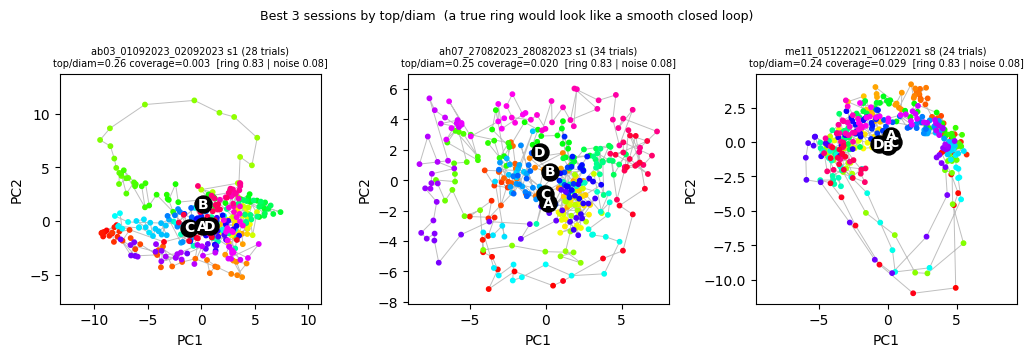

In [11]:
# Task-phase rings (written by run_taskphase_ring.py)
rings = {k: v for k, v in ph.load_ph_outputs(OUT_DIR).items() if v.get('state') == 'ring'}
print(f'{len(rings)} session rings')
if rings:
    best = sorted(rings.values(), key=lambda r: -r['geometry']['top_over_diameter'])[:3]
    fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.6))
    for ax, r in zip(axes, best):
        ph.plot_taskphase_ring(r, ax=ax)
    fig.suptitle('Best 3 sessions by top/diam  (a true ring would look like a smooth closed loop)',
                 fontsize=9)
    fig.tight_layout()
    if SAVE_FIGS: glm.save_section('fig7_ring_bestsessions', SAVE_DIR)
    plt.show()

top/diam : median 0.114  max 0.259   [true ring 0.83 | noise 0.08]
ring-like (top/diam > 0.5): 0/136


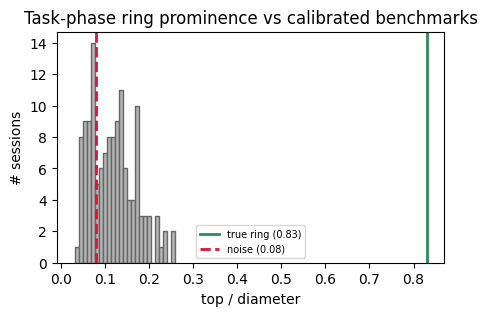

,mouse_recday,session,n_neurons,n_trials,top_over_diam,coverage,alignment,pc12_frac
1,ab03_01092023_02092023,1,63,28,0.258946,0.003236,0.003444,0.612511
66,ah07_27082023_28082023,1,80,34,0.254693,0.019689,0.021139,0.540082
118,me11_05122021_06122021,8,46,24,0.237033,0.028552,0.002635,0.617542
39,ah04_05122021_06122021,4,114,39,0.236780,0.060019,0.069221,0.499975
67,ah07_27082023_28082023,2,80,34,0.227892,0.012563,0.013502,0.527590
63,ah07_01092023_02092023,3,97,32,0.219091,0.015296,0.016300,0.571315
55,ah04_14122021_16122021,2,70,37,0.218889,0.056851,0.072716,0.550595
51,ah04_09122021_10122021,5,99,37,0.218843,0.003684,0.004948,0.585342
61,ah07_01092023_02092023,1,97,28,0.199736,0.016627,0.020648,0.560592
74,ah07_29082023_30082023,2,72,27,0.197674,0.032116,0.037526,0.547003


In [12]:
# cross-session summary vs the calibrated benchmarks
if rings:
    import pandas as pd
    df_ring = pd.DataFrame([dict(mouse_recday=r['mouse_recday'], session=r['session'],
                                 n_neurons=r['n_neurons'], n_trials=r['n_trials'],
                                 top_over_diam=r['geometry']['top_over_diameter'],
                                 coverage=r['coverage'], alignment=r['alignment'],
                                 pc12_frac=r['geometry']['pc12_frac'])
                            for r in rings.values()]).sort_values('top_over_diam', ascending=False)
    td = df_ring['top_over_diam'].values
    print(f"top/diam : median {np.median(td):.3f}  max {td.max():.3f}   [true ring 0.83 | noise 0.08]")
    print(f"ring-like (top/diam > 0.5): {(td > 0.5).sum()}/{len(td)}")
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.hist(td, bins=25, color='0.7', edgecolor='0.4')
    ax.axvline(0.83, color='seagreen', lw=2, label='true ring (0.83)')
    ax.axvline(0.08, color='crimson', lw=2, ls='--', label='noise (0.08)')
    ax.set_xlabel('top / diameter'); ax.set_ylabel('# sessions')
    ax.set_title('Task-phase ring prominence vs calibrated benchmarks'); ax.legend(fontsize=7)
    plt.show()
    display(df_ring.head(10))

## Fig 8 — Recday-averaged task-phase ring (cross-session abstraction)

For each recday, each neuron's 360-bin task-phase response is averaged across
**all sessions** (session-weighted, A-anchored). Since every session is a
*different reward configuration*, this cancels place/session-specific tuning and
keeps only what is consistent in abstract A->B->C->D phase — the best-powered,
most-abstract version of the ring test (69-239 pooled trials/recday).

Controls (`run_taskphase_ring.py --recday-average`): a synthetic recday whose
sessions share the same tuning (an abstract ring) gives top/diam **0.83**; pure
noise at matched N gives **0.068**. Caveat: a synthetic recday where each session
rings with re-randomised phases still scored 0.72, so top/diam alone can't tell
"abstract" from "per-session" — but the real per-session data has NO ring
(top/diam ~0.1) and noise pools to 0.07, so a high pooled value here would still
require genuine cross-session-consistent structure.

23 recday-averaged rings


save_section('fig8_ringavg_best'): wrote 1 file(s) to ../data/ph_outputs/figures


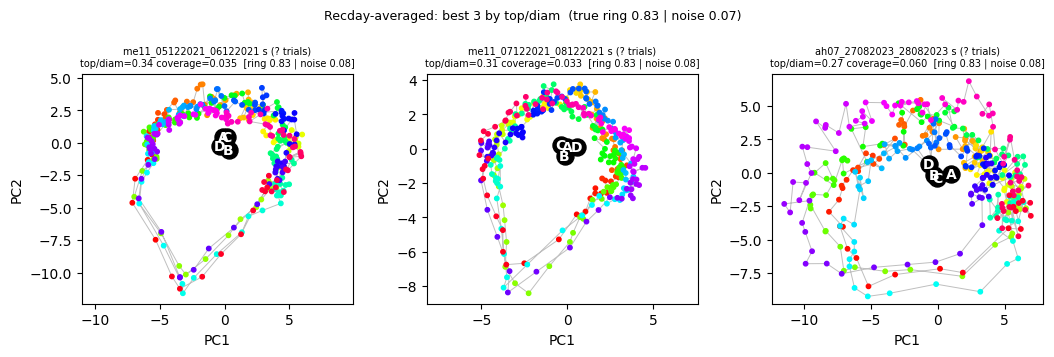

top/diam: median 0.207  max 0.336   ring-like (>0.5): 0/23


,mouse_recday,n_neurons,n_sessions,pooled_trials,top_over_diam,coverage,alignment
19,me11_05122021_06122021,46,9,268,0.336307,0.035253,0.002189
20,me11_07122021_08122021,24,8,274,0.308416,0.033042,0.005856
11,ah07_27082023_28082023,80,7,186,0.265886,0.060152,0.015670
10,ah07_01092023_02092023,97,7,160,0.251799,0.043446,0.013577
21,me11_09122021_10122021,26,9,282,0.249881,0.028934,0.005142
0,ab03_01092023_02092023,63,7,195,0.238925,0.024642,0.002085
2,ab03_29082023_30082023,70,9,175,0.232822,0.008515,0.008911
1,ab03_05092023_06092023,64,8,141,0.230928,0.006863,0.002824
12,ah07_29082023_30082023,72,7,142,0.219080,0.047028,0.006214
13,me08_06092021_09092021,23,8,99,0.211562,0.025405,0.003532


In [13]:
# recday-averaged rings (run_taskphase_ring.py --recday-average)
ringavg = {k: v for k, v in ph.load_ph_outputs(OUT_DIR).items() if v.get('state') == 'ringavg'}
print(f'{len(ringavg)} recday-averaged rings')
if ringavg:
    import pandas as pd
    td = np.array([r['geometry']['top_over_diameter'] for r in ringavg.values()])
    best = sorted(ringavg.values(), key=lambda r: -r['geometry']['top_over_diameter'])[:3]
    fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.6))
    for ax, r in zip(axes, best):
        ph.plot_taskphase_ring(r, ax=ax)
    fig.suptitle('Recday-averaged: best 3 by top/diam  (true ring 0.83 | noise 0.07)', fontsize=9)
    fig.tight_layout()
    if SAVE_FIGS: glm.save_section('fig8_ringavg_best', SAVE_DIR)
    plt.show()
    print(f'top/diam: median {np.median(td):.3f}  max {td.max():.3f}   ring-like (>0.5): {(td>0.5).sum()}/{len(td)}')
    df_avg = pd.DataFrame([dict(mouse_recday=r['mouse_recday'], n_neurons=r['n_neurons'],
                                n_sessions=r['n_sessions'], pooled_trials=r['n_trials_total'],
                                top_over_diam=r['geometry']['top_over_diameter'],
                                coverage=r['coverage'], alignment=r['alignment'])
                           for r in ringavg.values()]).sort_values('top_over_diam', ascending=False)
    display(df_avg.head(12))

## Fig 9 — Goal-progress structure (the dominant code)

The recday-averaged trajectory **repeats every 90 bins**, not 360: the code is
organised by **goal progress** (within-leg 0->1), with A/B/C/D *identity* nearly
absent. `leg_similarity` = mean pairwise correlation of the 4 legs' tuning
(**~1 = legs identical / goal-progress dominated**; ~0 = unique per task-phase).
Real LEC/PFC sit at ~0.99 — calibrated against synthetic controls
(`controls_placecells.py`): speed 1.00, place*speed 0.94, session-inconsistent
place 0.27, abstract-360 ring -0.33.

Folding the 360 bins into 90 (averaging the 4 legs) isolates the goal-progress
code. It lifts top/diam (identity was barely there) but stays well below a ring:
the folded trajectory is an **open horseshoe ARC** (distance-to-reward sweep),
not a closed loop. So the dominant, universal structure is a goal-progress
manifold — real, but an arc, not a topological ring.

In [14]:
# leg-similarity + folded goal-progress top/diam across recdays
if ringavg:
    import pandas as pd
    df_gp = pd.DataFrame([dict(mouse_recday=r['mouse_recday'], n_neurons=r['n_neurons'],
                               leg_similarity=r.get('leg_similarity', np.nan),
                               top_over_diam_360=r['geometry']['top_over_diameter'],
                               fold_top_over_diam_90=r.get('fold', {}).get('top_over_diameter', np.nan),
                               fold_coverage=r.get('fold', {}).get('coverage', np.nan))
                          for r in ringavg.values()]).sort_values('fold_top_over_diam_90', ascending=False)
    print(f"leg_similarity median {df_gp.leg_similarity.median():.2f} "
          f"(1=goal-progress dominated | speed synth 1.00 | abstract-ring -0.33)")
    print(f"folded (goal-progress) top/diam median {df_gp.fold_top_over_diam_90.median():.2f} "
          f"vs 360 {df_gp.top_over_diam_360.median():.2f}   [ring 0.83 | noise 0.07]")
    display(df_gp.head(10))

leg_similarity median 0.97 (1=goal-progress dominated | speed synth 1.00 | abstract-ring -0.33)
folded (goal-progress) top/diam median 0.24 vs 360 0.21   [ring 0.83 | noise 0.07]


,mouse_recday,n_neurons,leg_similarity,top_over_diam_360,fold_top_over_diam_90,fold_coverage
11,ah07_27082023_28082023,80,0.983137,0.265886,0.424660,0.048930
12,ah07_29082023_30082023,72,0.984114,0.219080,0.335345,0.040200
10,ah07_01092023_02092023,97,0.976285,0.251799,0.332150,0.049656
14,me08_10092021_11092021,32,0.986507,0.188201,0.327486,0.031231
6,ah04_05122021_06122021,114,0.966824,0.206895,0.319788,0.042652
0,ab03_01092023_02092023,63,0.965347,0.238925,0.310526,0.021335
13,me08_06092021_09092021,23,0.987658,0.211562,0.281774,0.025941
2,ab03_29082023_30082023,70,0.950470,0.232822,0.263481,0.014503
9,ah04_14122021_16122021,70,0.965531,0.190795,0.252517,0.065487
8,ah04_09122021_10122021,99,0.988323,0.207166,0.252373,0.041639


save_section('fig9_goalprogress_ah07_27082023_28082023'): wrote 1 file(s) to ../data/ph_outputs/figures


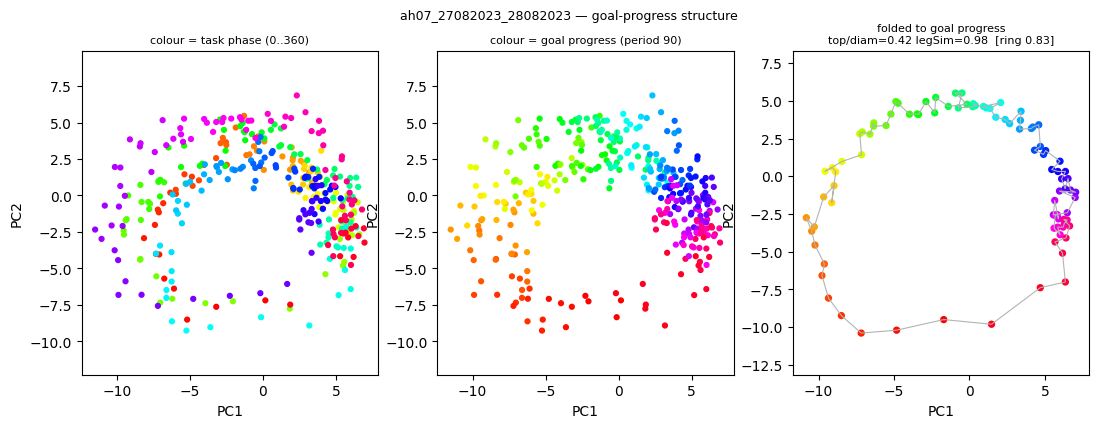

In [15]:
# 3-panel goal-progress view of the recday with the clearest folded arc
if ringavg:
    best_gp = max(ringavg.values(), key=lambda r: r.get('fold', {}).get('top_over_diameter', 0))
    fig = ph.plot_goalprogress(best_gp)
    if SAVE_FIGS: glm.save_section('fig9_goalprogress_' + best_gp['mouse_recday'], SAVE_DIR)
    plt.show()

In [16]:
# synthetic place-cell + speed-modulation control (through the SAME pipeline)
import controls_placecells as cpc
import pandas as pd
ctrl_rows = cpc.run(verbose=False)
display(pd.DataFrame(ctrl_rows))
print("real LEC/PFC: leg_similarity ~0.99 (matches speed 1.00), fold top/diam ~0.26 "
      "-> goal-progress ARC, not a ring; pure speed is 1-D (0.02), place is session-inconsistent.")

,model,top_over_diam,coverage,leg_similarity,fold_top_over_diam
0,place,0.197318,0.174705,0.270036,0.044428
1,speed,0.021701,0.007500,0.997633,0.009509
2,place_speed,0.131677,0.135472,0.935908,0.020366
3,TRUE ring (ctl),0.826608,0.882852,-0.331518,0.499090


real LEC/PFC: leg_similarity ~0.99 (matches speed 1.00), fold top/diam ~0.26 -> goal-progress ARC, not a ring; pure speed is 1-D (0.02), place is session-inconsistent.


## Fig 10 — H1 barcodes (recday-averaged)

Persistence **barcodes** of the recday-averaged rings: each horizontal line is an
H1 feature (birth->death). A genuine ring shows **one long bar far above the
rest** (the reference panel, ratio ~27); the real recdays instead show a
**staircase of similar-length bars** (ratio ~1-3), the signature of no dominant
loop. Shown for the full 360-bin task phase and for the folded goal-progress
cloud. `ratio` in each title = longest / 2nd-longest bar.

save_section('fig10_barcodes_full'): wrote 1 file(s) to ../data/ph_outputs/figures


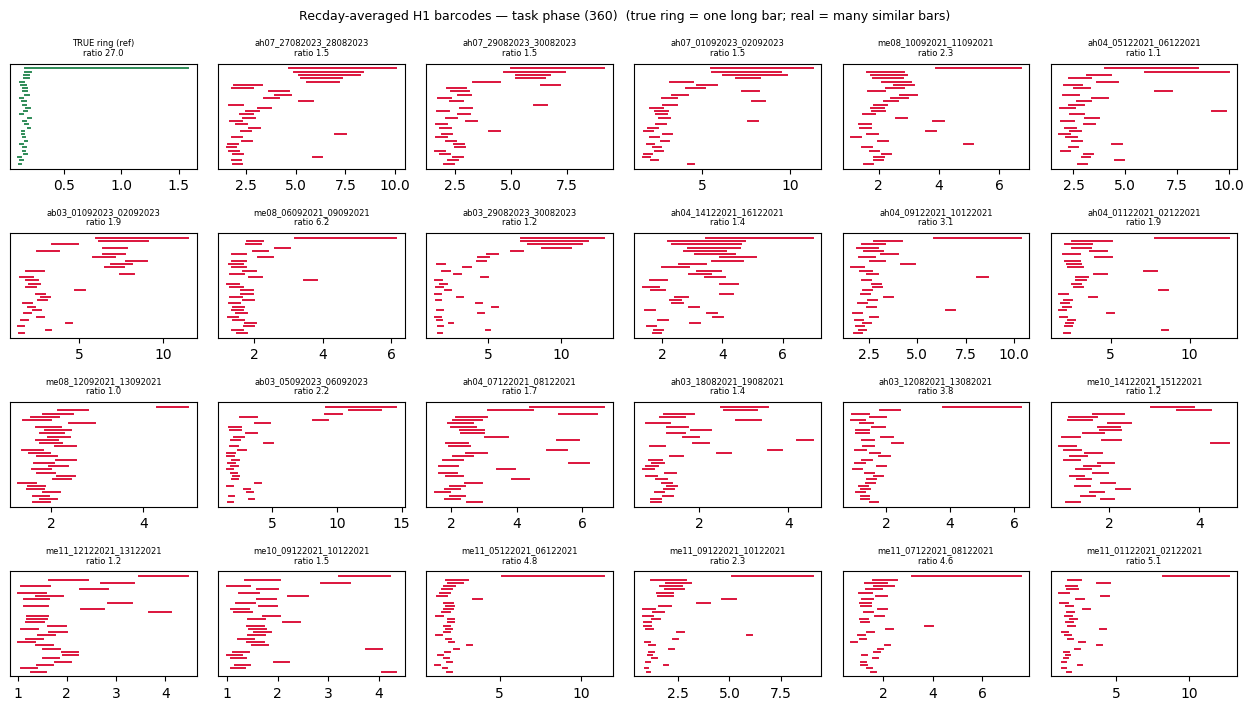

save_section('fig10_barcodes_fold'): wrote 1 file(s) to ../data/ph_outputs/figures


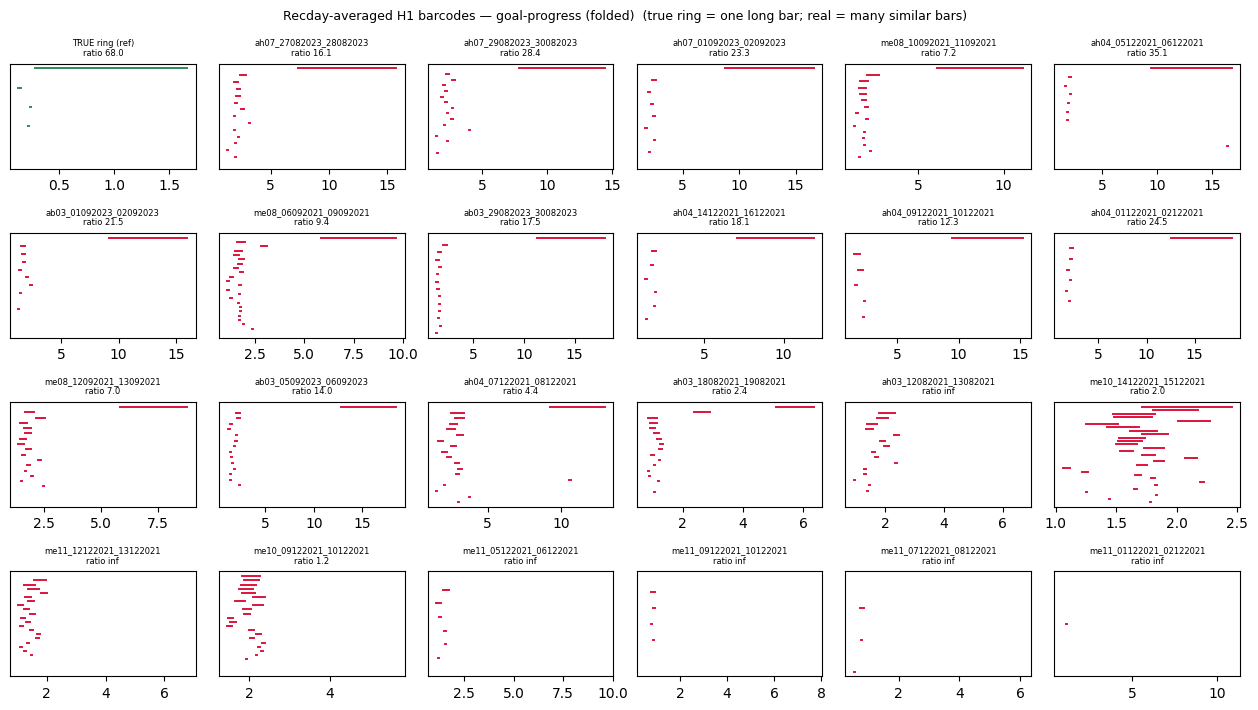

In [17]:
# H1 barcode small-multiples: full task-phase + folded goal-progress
if ringavg:
    fig = ph.plot_ringavg_barcode_grid(ringavg, which='full', ncols=6)
    if SAVE_FIGS: glm.save_section('fig10_barcodes_full', SAVE_DIR)
    plt.show()
    fig = ph.plot_ringavg_barcode_grid(ringavg, which='fold', ncols=6)
    if SAVE_FIGS: glm.save_section('fig10_barcodes_fold', SAVE_DIR)
    plt.show()

## Fig 11 — Real-behaviour place/speed control (2D + 3D)

The earlier place/speed synthetics used an idealized cartoon maze. Here the
synthetic cells are driven by the recday's **real behaviour** — actual `XY_raw`
positions, real speed, real reward configs — warped to task phase with the same
90x4 grid, then run through the identical recday-averaged pipeline. Four cell
types + the REAL neural data, each shown 2D (goal-progress colour) / folded / 3D.

Result: **none of place / speed / place+speed / goalprog reproduces the real arc.**
`place` folds moderately but legs *differ* (legSim ~0.3, session-inconsistent);
`speed` is 1-D; a simple `goalprog` (distance-to-reward) cell matches the period-90
consistency (legSim ~1) but is geometrically too thin (fold_td ~0.13). The REAL
folded arc (fold_td ~0.39, legSim 0.99) is a genuine, richer 2-D goal-progress /
distance-to-reward manifold — not physical place, not speed.

real-behaviour control on ah07_27082023_28082023


save_section('fig11_realbehaviour_ah07_27082023_28082023'): wrote 1 file(s) to ../data/ph_outputs/figures


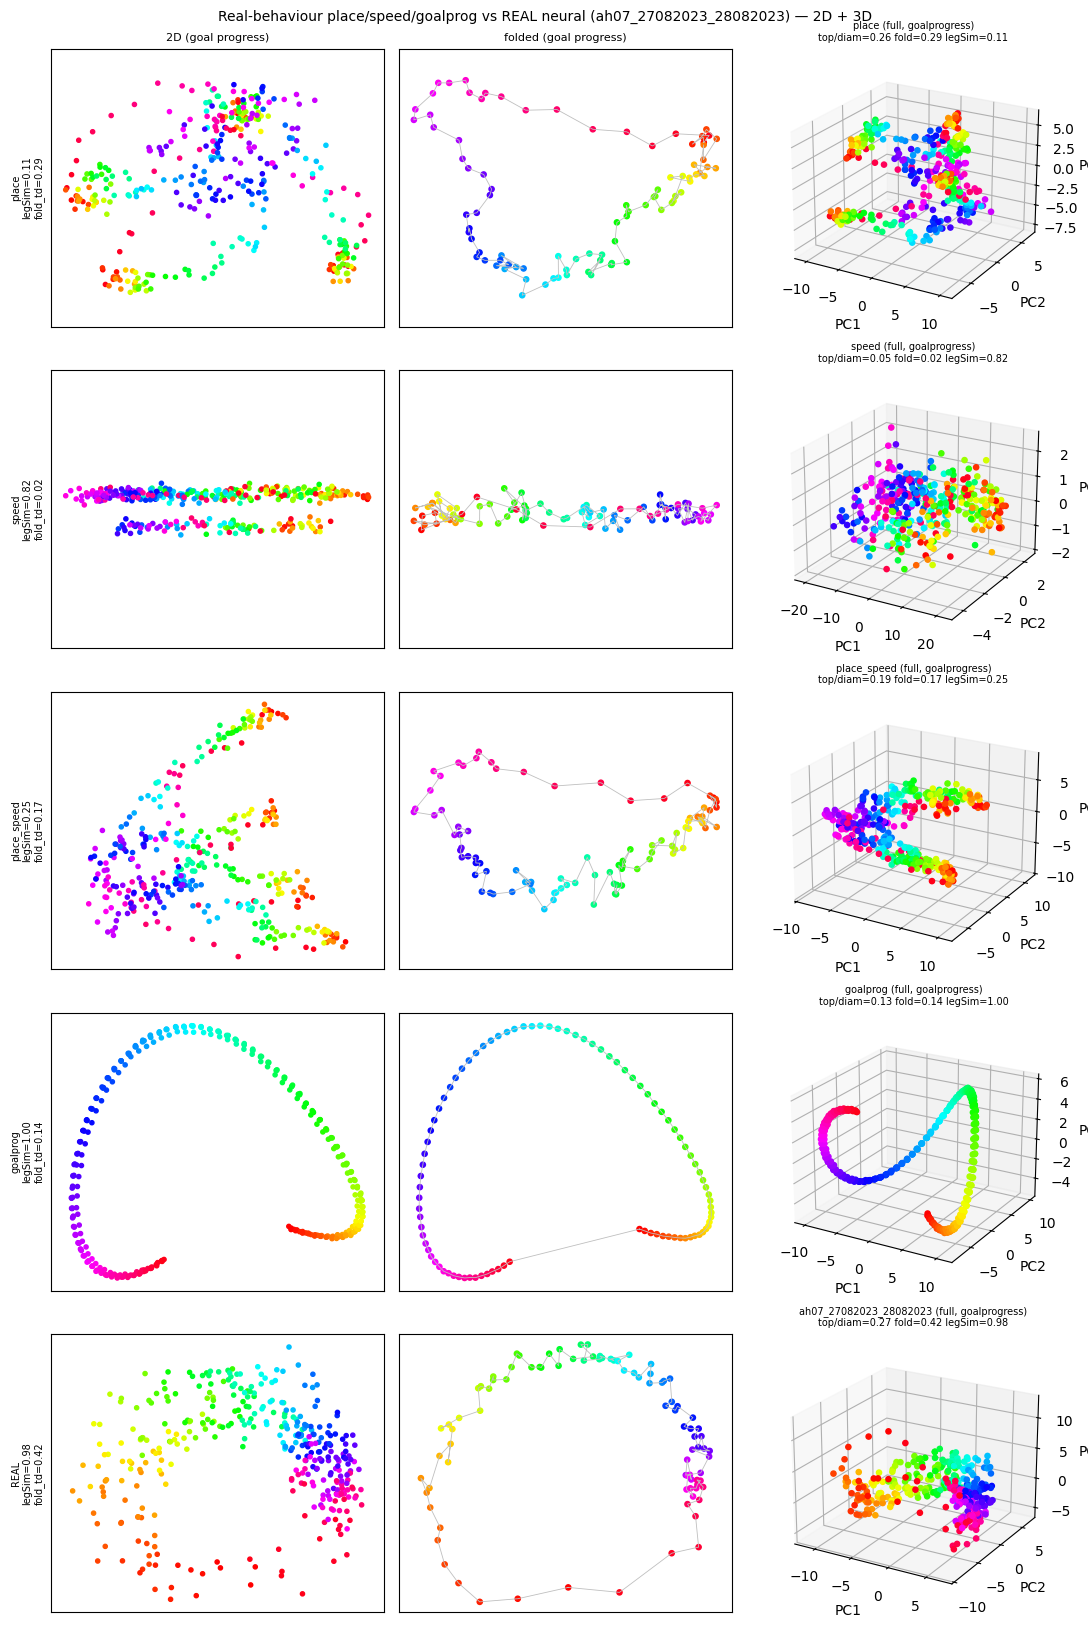

,model,top_over_diam,coverage,leg_similarity,fold_top_over_diam
0,place,0.258,0.149,0.108,0.294
1,speed,0.048,0.110,0.819,0.018
2,place_speed,0.195,0.014,0.247,0.174
3,goalprog,0.129,0.237,0.999,0.135
4,REAL neural,0.266,0.060,0.983,0.425


In [18]:
# real-behaviour control (loads raw behaviour for the best-fold recday)
import os, pickle, pandas as pd, controls_placecells as cpc
cfg_rb = ph.PHConfig(coeff_fields=(2,), n_pca=6)
if ringavg:
    rb_name = max(ringavg.values(), key=lambda r: r['fold']['top_over_diameter'])['mouse_recday']
    if os.path.exists('../data/processed_data/data_dic_lec.pkl'):        # LEC
        rday = glm.load_data_dic('../data/processed_data/data_dic_lec.pkl')[rb_name]
    else:                                                                # PFC (light build)
        rday = glm.build_data_dic_from_pfc('../data', [rb_name], verbose=False)[rb_name]
    real_rb = next(v for v in ringavg.values() if v['mouse_recday'] == rb_name)
    print(f'real-behaviour control on {rb_name}')
    fig, rows = cpc.plot_real_behaviour_comparison(rday, cfg_rb, real_rb)
    if SAVE_FIGS: glm.save_section('fig11_realbehaviour_' + rb_name, SAVE_DIR)
    plt.show()
    display(pd.DataFrame(rows).round(3))

## Fig 12 — PCA loop array (recday-averaged)

The recday-averaged trajectories themselves, one panel per recday (same layout /
sort / reference as the barcode grids), colour = bin index. `full` = 360-bin task
phase (A/B/C/D centroids clump in the centre — identity is averaged away, and the
colour wheel repeats ~4x per loop); `fold` = folded 90-bin goal-progress loop.
The clean-circle reference (top-left) is what a true ring looks like; the real
recdays are open horseshoe **arcs**, strongest for the high top/diam ones.

save_section('fig12_loops_full'): wrote 1 file(s) to ../data/ph_outputs/figures


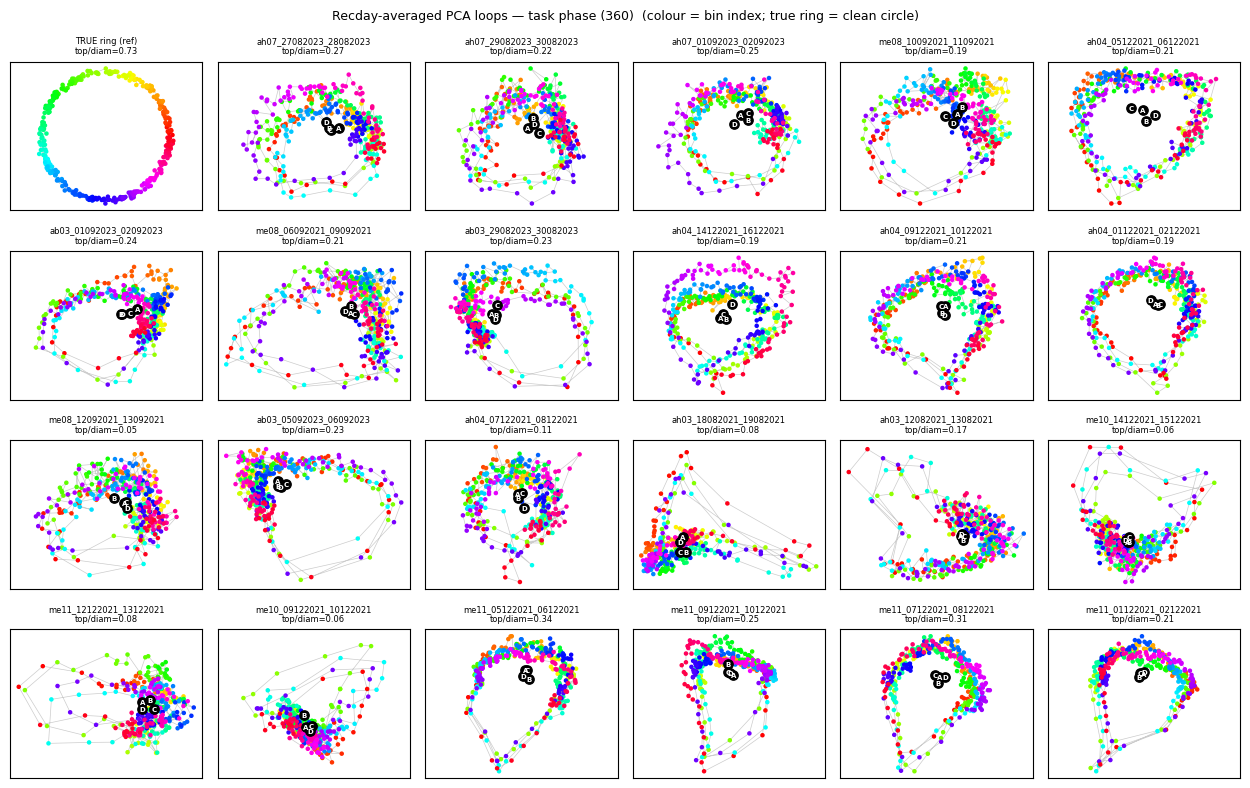

save_section('fig12_loops_fold'): wrote 1 file(s) to ../data/ph_outputs/figures


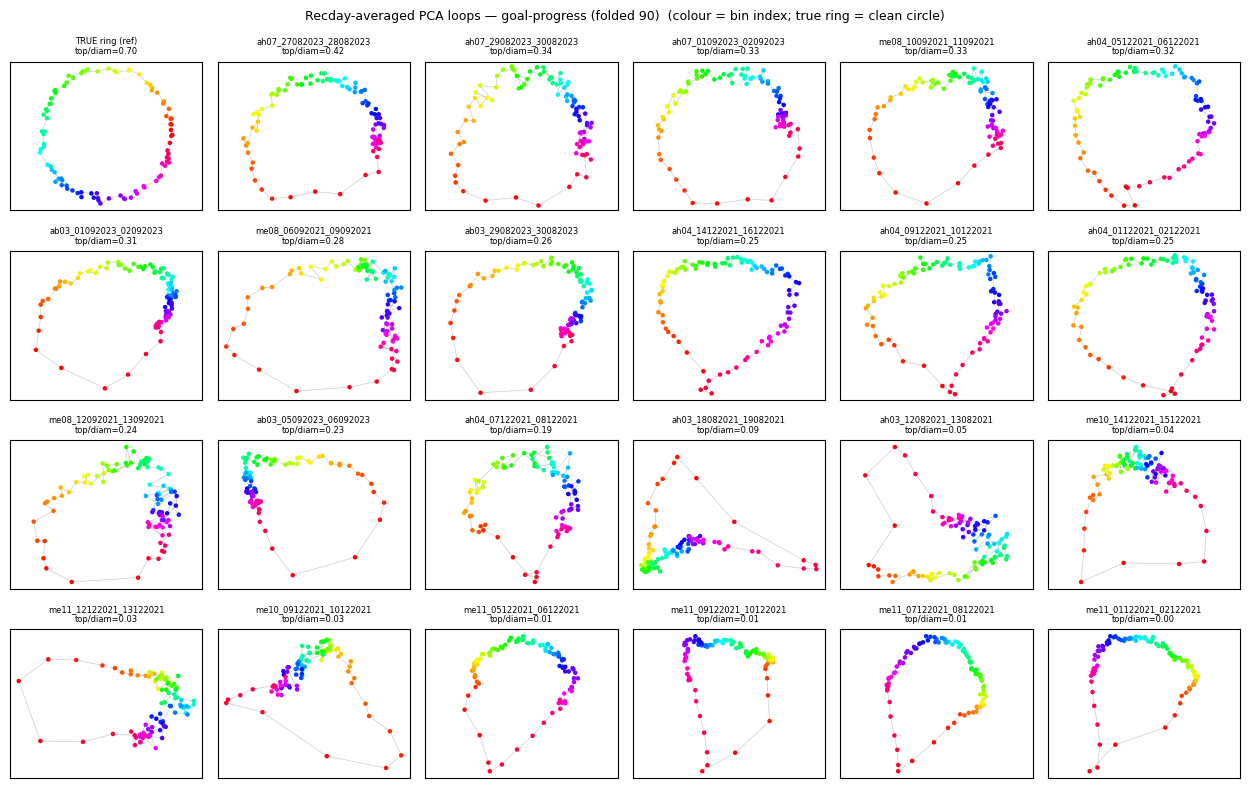

In [19]:
# PCA loop small-multiples: full task-phase + folded goal-progress
if ringavg:
    fig = ph.plot_ringavg_loop_grid(ringavg, which='full', ncols=6)
    if SAVE_FIGS: glm.save_section('fig12_loops_full', SAVE_DIR)
    plt.show()
    fig = ph.plot_ringavg_loop_grid(ringavg, which='fold', ncols=6)
    if SAVE_FIGS: glm.save_section('fig12_loops_fold', SAVE_DIR)
    plt.show()

---
### Interpretation guide
- **Significant H1 ring**: one H1 bar with high top/second ratio **and** `H1_p < 0.05`
  vs the per-neuron circular-shift null. The decoded θ should track `task_phase`
  (`task_phase_R` high, `p` small) for the ring to be the *task* ring.
- **Torus**: two long H1 bars **and** a long H2 bar (`H2_ratio ≫ 1`) — rerun the
  batch with the toroidal-coordinate path if this appears.
- **Sleep preservation / replay**: sleep θ(t) moves smoothly
  (`replay_p_continuity < 0.05`) **and** actually explores the ring
  (`replay_coverage` well above 0) ⇒ the wake manifold is
  traversed during sleep.
- A flat barcode (ratios ≈ 1, `H1_p` n.s.) is the honest **null result**: no
  low-dimensional ring in instantaneous activity at these settings.